In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'

### Train a model for a single config file

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [3]:
! ls /global/home/users/ann_scheliga/neuralhydrology/runs/

EXP00_1basin_cbr_no_sw_0508_101608
EXP00_1basin_cbr_no_sw_lossMSE_0508_102017
EXP00_1basin_cbr_wi_sw_0508_100309
EXP00_1basin_cbr_wi_sw_lossMSE_0508_101940
notebook_lstm_preprocess_input_2707_173454
notebook_lstm_preprocess_input_2707_174001
notebook_lstm_preprocess_input_2707_174032
notebook_lstm_preprocess_input_2707_174530
notebook_lstm_preprocess_input_2707_174636
notebook_lstm_preprocess_input_2707_174906
notebook_lstm_preprocess_input_2707_174926
notebook_two_var_only_0907_131306
notebook_two_var_only_0907_142954


## EVALUATION

In [4]:
sw_run_dir = Path(all_runs_dir,"EXP00_1basin_cbr_wi_sw_lossMSE_0508_101940")
print(sw_run_dir)
eval_run(run_dir=sw_run_dir, period="test")
eval_run(run_dir=sw_run_dir, period="train")
eval_run(run_dir=sw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_1basin_cbr_wi_sw_lossMSE_0508_101940
# Validation: 100%|██████████| 1/1 [00:00<00:00, 14.87it/s]


In [5]:
nosw_run_dir = Path(all_runs_dir,"EXP00_1basin_cbr_no_sw_lossMSE_0508_102017")
print(nosw_run_dir)
eval_run(run_dir=nosw_run_dir, period="test")
eval_run(run_dir=nosw_run_dir, period="train")
eval_run(run_dir=nosw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_1basin_cbr_no_sw_lossMSE_0508_102017
# Validation: 100%|██████████| 1/1 [00:00<00:00, 15.22it/s]


### Load and inspect model predictions TRAINING
Next, we load the results file and compare the model predictions with observations. The results file is always a pickled dictionary with one key per basin (even for a single basin). The next-lower dictionary level is the temporal resolution of the predictions. In this case, we trained a model only on daily data ('1D'). Within the temporal resolution, the next-lower dictionary level are `xr`(an xarray Dataset that contains observations and predictions), as well as one key for each metric that was specified in the config file.

In [6]:
with open(sw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    sw_train_results = pickle.load(fp)
    
sw_train_results.keys()

dict_keys(['4152450'])

In [7]:
with open(nosw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    nosw_train_results = pickle.load(fp)
    
nosw_train_results.keys()

dict_keys(['4152450'])

In [8]:
with open(sw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    sw_test_results = pickle.load(fp)
    
sw_test_results.keys()

dict_keys(['4152450'])

In [9]:
with open(nosw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    nosw_test_results = pickle.load(fp)
    
nosw_test_results.keys()

dict_keys(['4152450'])

In [14]:
def plot_obs_sim_timeseries(ax, nh_dict,period=''):
    qobs = nh_dict['xr']['Q_obs']
    qsim = nh_dict['xr']['Q_sim']
    
    ax.plot(qobs['date'], qobs, c='k',label='obs')
    ax.plot(qsim['date'], qsim, c='b',label='sim')
    ax.set_ylabel("Discharge (mm/d)")
    ax.set_title(f"{period} period - NSE {nh_dict['NSE']:.3f}")
    values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
    print('----',period, 'METRICS----')
    for key, val in values.items():
        print(f"{key}: {val:.3f}")

---- SW train METRICS----
NSE: 0.635
MSE: 891.915
RMSE: 29.865
KGE: 0.659
Alpha-NSE: 0.723
Beta-KGE: 0.999
Beta-NSE: -0.006
Pearson-r: 0.801
FHV: -19.023
FMS: -15.262
FLV: 87.690
Peak-Timing: 2.429
Peak-MAPE: 16.183
---- SW test METRICS----
NSE: -0.349
MSE: 34074.840
RMSE: 184.594
KGE: -0.779
Alpha-NSE: 0.087
Beta-KGE: 0.781
Beta-NSE: -0.502
Pearson-r: -0.511
FHV: -69.505
FMS: -87.770
FLV: 78.882
Peak-Timing: 3.000
Peak-MAPE: 75.386
---- No SW train METRICS----
NSE: 0.694
MSE: 928.340
RMSE: 30.469
KGE: 0.710
Alpha-NSE: 0.760
Beta-KGE: 0.997
Beta-NSE: -0.015
Pearson-r: 0.837
FHV: -14.220
FMS: -22.592
FLV: 83.720
Peak-Timing: 1.778
Peak-MAPE: 15.228
---- No SW test METRICS----
NSE: -0.197
MSE: 30229.879
RMSE: 173.867
KGE: -0.737
Alpha-NSE: 0.092
Beta-KGE: 0.861
Beta-NSE: -0.318
Pearson-r: -0.474
FHV: -66.281
FMS: -93.635
FLV: 22.944
Peak-Timing: 0.000
Peak-MAPE: 71.468


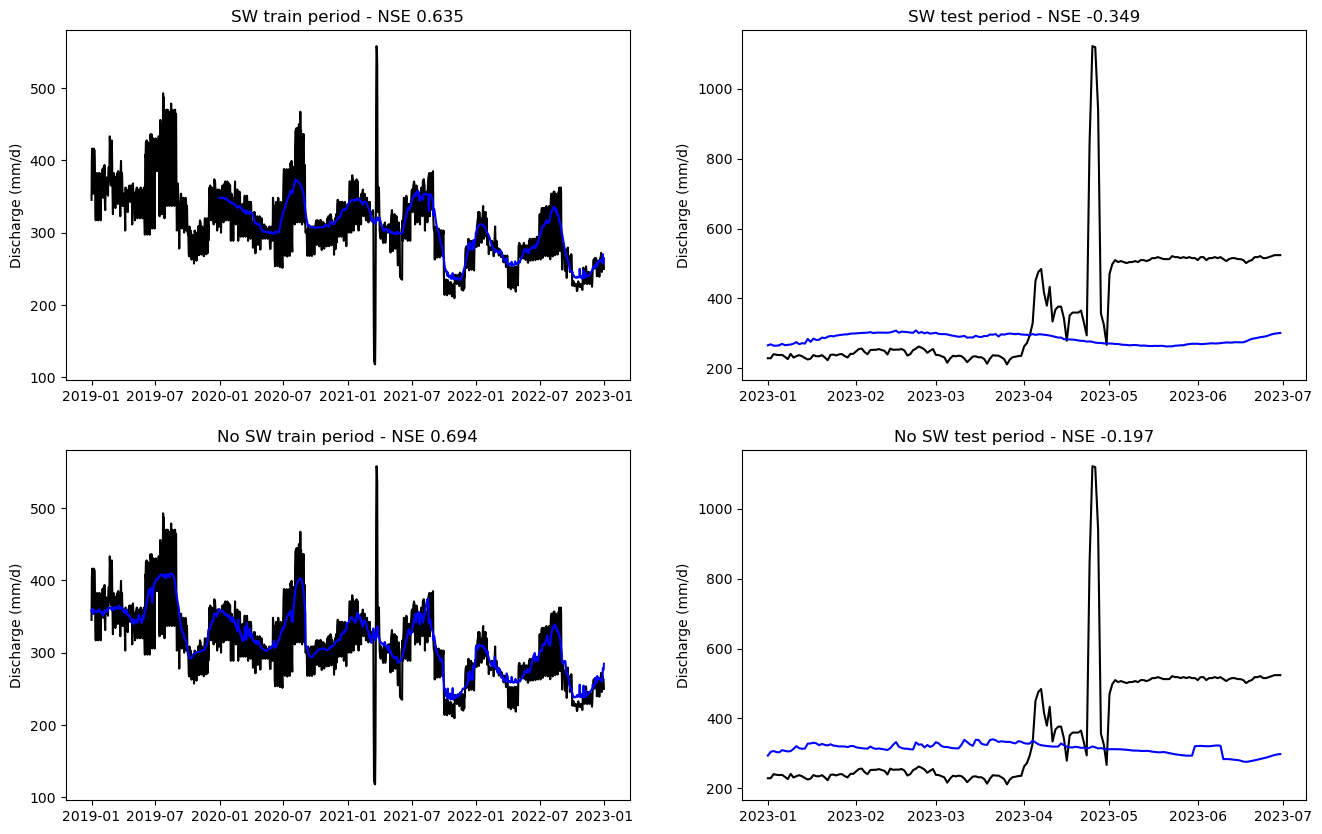

In [15]:
fig, axs = plt.subplots(2,2,figsize=(16,10))

plot_obs_sim_timeseries(axs[0,0],sw_train_results['4152450']['1D'],'SW train')
plot_obs_sim_timeseries(axs[0,1],sw_test_results['4152450']['1D'],'SW test')
plot_obs_sim_timeseries(axs[1,0],nosw_train_results['4152450']['1D'],'No SW train')
plot_obs_sim_timeseries(axs[1,1],nosw_test_results['4152450']['1D'],'No SW test')